<a href="https://colab.research.google.com/github/vaibhavm291/PROTOTYPES-/blob/main/DEM%2BGIS_INTEGRATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install rasterio geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 82.2 MB/s eta 0:00:00


In [ ]:
import rasterio
import geopandas as gpd
from shapely.geometry import shape

In [ ]:
import rasterio
import matplotlib.pyplot as plt


In [ ]:
import json
from google.colab.patches import cv2_imshow
from google.colab import files
uploaded = files.upload()

Saving P5_PAN_CD_N22_000_E082_000_DEM_30m.tif to P5_PAN_CD_N22_000_E082_000_DEM_30m.tif


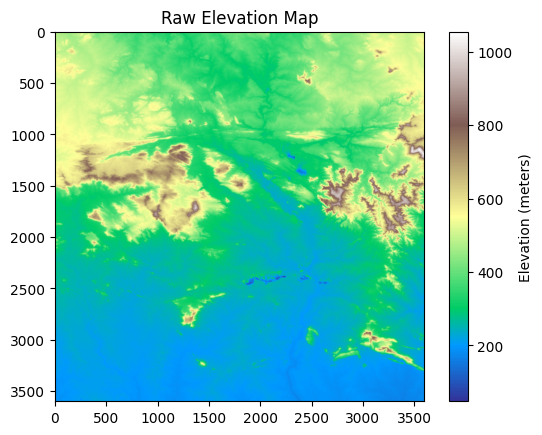

In [ ]:
dem_path = 'P5_PAN_CD_N22_000_E082_000_DEM_30m.tif'

with rasterio.open(dem_path) as src:
    elevation = src.read(1)  # 2D numpy array
    transform = src.transform
    crs = src.crs

plt.imshow(elevation, cmap='terrain')
plt.colorbar(label='Elevation (meters)')
plt.title("Raw Elevation Map")
plt.show()

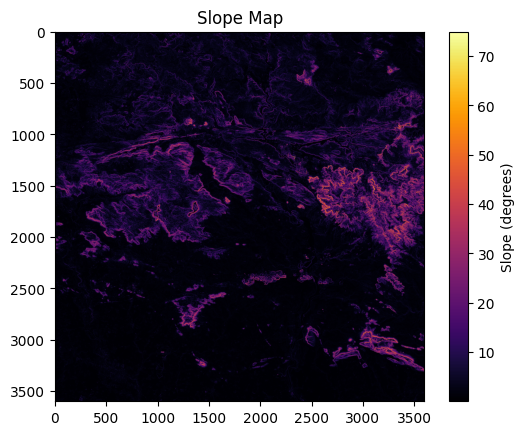

In [ ]:
import numpy as np

def compute_slope(elevation, pixel_size):
    dzdx = np.gradient(elevation, axis=1) / pixel_size
    dzdy = np.gradient(elevation, axis=0) / pixel_size
    slope = np.sqrt(dzdx**2 + dzdy**2)
    return np.degrees(np.arctan(slope))

pixel_size = 30  # Adjust based on your .tif (often 30m resolution)
slope_map = compute_slope(elevation, pixel_size)

plt.imshow(slope_map, cmap='inferno')
plt.colorbar(label='Slope (degrees)')
plt.title("Slope Map")
plt.show()


In [ ]:
# Create zone masks
pooling_zone = slope_map < 2      # Risk of water pooling 🟥
safe_zone    = (slope_map >= 2) & (slope_map <= 5)  # Good for construction 🟩
steep_zone   = slope_map > 10     # Too steep → needs retaining 🟨

# Create a visual map
risk_map = np.zeros_like(slope_map)

# Assign class IDs (just for color mapping later)
risk_map[pooling_zone] = 1   # 🟥
risk_map[safe_zone]    = 2   # 🟩
risk_map[steep_zone]   = 3   # 🟨


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127959 (\N{BUILDING CONSTRUCTION}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


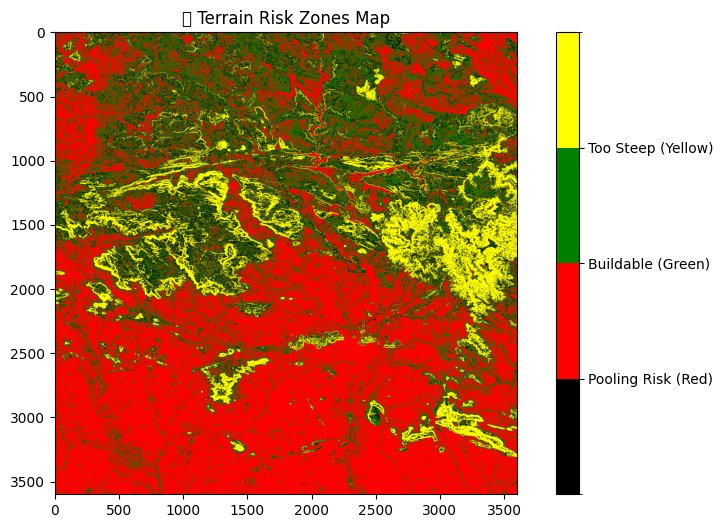

In [ ]:
import matplotlib.colors as colors

# Define custom color map
cmap = colors.ListedColormap(['black', 'red', 'green', 'yellow'])
bounds = [0, 1, 2, 3, 4]
norm = colors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(10, 6))
plt.imshow(risk_map, cmap=cmap, norm=norm)
plt.title("🏗️ Terrain Risk Zones Map")
plt.colorbar(ticks=[1, 2, 3], format=plt.FuncFormatter(lambda val, _: {1: "Pooling Risk (Red)", 2: "Buildable (Green)", 3: "Too Steep (Yellow)"}.get(val, '')))
plt.show()


In [ ]:
from rasterio import Affine
from rasterio.transform import from_origin
import rasterio

In [ ]:
# Open the DEM again to get metadata
with rasterio.open(dem_path) as src:
    profile = src.profile
    transform = src.transform
    crs = src.crs

# Update profile for the risk map
profile.update(
    dtype=rasterio.uint8,
    count=1,
    compress='lzw',
    nodata=None # Remove nodata value as it's not compatible with uint8
)

# Remove crs and transform from profile before unpacking
del profile['crs']
del profile['transform']


# Save risk map as GeoTIFF
with rasterio.open("P5_PAN_CD_N22_000_E082_000_DEM_30m.tif", 'w', transform=transform, crs=crs, **profile) as dst:
    dst.write(risk_map.astype(rasterio.uint8), 1)

In [ ]:
from rasterio.transform import from_origin

# Replace with real-world lat/lon of top-left corner
lon_top_left = 82.1234
lat_top_left = 22.5678

pixel_size = 30  # adjust if needed
transform = from_origin(lon_top_left, lat_top_left, pixel_size, pixel_size)

crs = 'EPSG:4326'  # WGS84


In [ ]:
profile.update(transform=transform, crs=crs)


In [ ]:
import numpy as np
import rasterio
from rasterio.features import shapes
import geopandas as gpd
from shapely.geometry import shape

# Open the processed GeoTIFF
with rasterio.open("P5_PAN_CD_N22_000_E082_000_DEM_30m.tif") as src:
    image = src.read(1)
    mask = image > 0  # only where slope exists
    results = (
        {"properties": {"risk": int(v)}, "geometry": shape(s)}
        for s, v in shapes(image, mask=mask, transform=src.transform)
    )

# Create GeoDataFrame
gdf = gpd.GeoDataFrame.from_features(list(results), crs=src.crs)

# Save to GeoJSON
gdf.to_file("slope_risk.geojson", driver="GeoJSON")


In [ ]:
gdf = gpd.GeoDataFrame.from_features(list(results), crs=src.crs)


In [ ]:
if not gdf.empty:
    gdf.to_file("slope_risk.geojson", driver="GeoJSON")
else:
    print("⚠️ No features found — GeoJSON not saved.")


In [ ]:
print(np.unique(risk_map))


[0. 1. 2. 3.]


In [ ]:
from shapely.geometry import shape
from rasterio.features import shapes
import geopandas as gpd
import rasterio
import numpy as np

# Open the processed GeoTIFF
with rasterio.open("P5_PAN_CD_N22_000_E082_000_DEM_30m.tif") as src:
    image = src.read(1)
    mask = image > 0  # only where slope exists
    transform = src.transform
    crs = src.crs

    # Extract polygons for non-zero areas
    results = (
        {"properties": {"risk": int(v)}, "geometry": shape(s)}
        for s, v in shapes(image.astype(np.uint8), mask=mask, transform=transform)
    )

# Create GeoDataFrame
results_list = list(results)

if results_list:
    gdf = gpd.GeoDataFrame.from_features(results_list, crs=crs)
    # Save it!
    gdf.to_file("slope_risk.geojson", driver="GeoJSON")
    print("GeoJSON file 'slope_risk.geojson' created successfully.")
else:
    print("⚠️ No features found — GeoJSON not saved.")

GeoJSON file 'slope_risk.geojson' created successfully.


<Axes: >

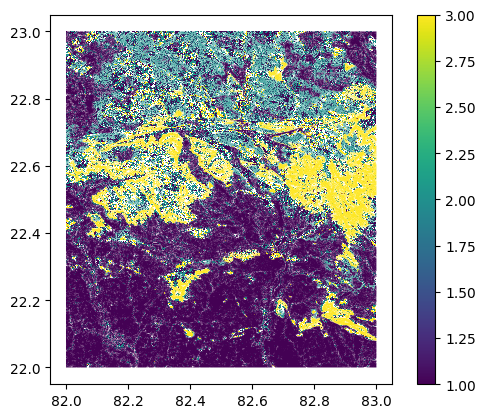

In [ ]:
gdf.plot(column="risk", legend=True)


In [ ]:
gdf.crs = crs


In [ ]:
gdf.to_file("slope_risk.geojson", driver="GeoJSON")


In [ ]:
gis = gpd.read_file("slope_risk.geojson")


In [ ]:
gdf.crs = "EPSG:4326"  # WGS84 - lat/lon


In [ ]:
gis = gis.to_crs(gdf.crs)


In [ ]:
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box
from shapely.geometry import shape

# --- Step 1: Load DEM ---
with rasterio.open("P5_PAN_CD_N22_000_E082_000_DEM_30m.tif") as src:
    elevation = src.read(1)
    transform = src.transform

# --- Step 2: Compute Slope ---
def compute_slope(elevation, pixel_size):
    dzdx = np.gradient(elevation, axis=1) / pixel_size
    dzdy = np.gradient(elevation, axis=0) / pixel_size
    slope = np.sqrt(dzdx**2 + dzdy**2)
    return np.degrees(np.arctan(slope))

slope = compute_slope(elevation, pixel_size=30)

# --- Step 3: Classify Risk Zones (low slope = pooling) ---
risk = np.zeros_like(slope)
risk[slope < 2] = 1  # High pooling risk
risk[slope > 10] = 2  # Too steep
risk[(slope >= 2) & (slope <= 5)] = 3  # Ideal

# --- Step 4: Convert Risk Map to GeoDataFrame ---
rows, cols = np.where(risk > 0)
xs, ys = rasterio.transform.xy(transform, rows, cols)
geoms = [box(x-15, y-15, x+15, y+15) for x, y in zip(xs, ys)]  # 30m pixel
gdf = gpd.GeoDataFrame({'risk': risk[rows, cols]}, geometry=geoms, crs="EPSG:4326")

# 🧹 Optional: Simplify geometries to speed up
gdf["geometry"] = gdf["geometry"].simplify(0.0005)

# --- Step 5: Load GIS Civic Infra Layer (roads, drains) ---
gis = gpd.read_file("slope_risk.geojson")
gis = gis.to_crs(gdf.crs)

# --- Step 6: Spatial Join (MUCH faster than overlay) ---
joined = gpd.sjoin(gdf, gis, how="inner", predicate="intersects")

# --- Step 7: Plot and Done! ---
gdf.plot(column="risk", cmap="viridis", legend=True)
plt.title("Risk Zones from DEM")
plt.show()

joined.plot()
plt.title("Zones Intersecting Civic Infra")
plt.show()


In [ ]:
from shapely.geometry import Point

# Example: where slope zones overlap with GIS lines (e.g. drains)
overlay = gpd.overlay(gdf, gis, how='intersection')